In [ ]:
!pip install

In [157]:
import pandas as pd
import re
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import inspect
import sklearn

from sklearn.datasets import load_iris,load_wine, load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

# pandas, matplotlib, seaborn, scikit-learn 설치해야함 !pip3 install ~~
# pandas
# 2차원 데이터 (엑셀 표, DataBase의 Table, 수학의 Matrix)
# DataFrame
# 행( row ), 열( column )

In [ ]:
df_train = pd.read_csv("서울시 지하철호선별 역별 승하차 인원 정보.csv", encoding="EUC-KR")
df_train.info()

# DataFram명["컬럼명"]
df_train["역명"]

# 슬라이싱
# DataFrame명[["컬럼명1", "컬럼명2", ..., "컬럼명10"]]
df_train[["역명", "승차총승객수"]]

# 인덱싱 값을 통해 접근하는 방법 : loc(location)
# DataFrame명.loc[행 인덱싱 값, 열 인덱싱 값]
# row 는 오왼, column 은 위아래
df_train.loc[2, "승차총승객수"]

df_train.loc[2]

# 0~10, 원래 슬라이싱은 0~9인것에 유의@@
df_train.loc[:10, "호선명":"승차총승객수"]

# iloc(integer location 의 준말)
df_train.iloc[2]

# 원래 슬라이싱과 같이 2이상 5미만
df_train.iloc[2:5]
df_train.iloc[:5, :4]


<class 'pandas.DataFrame'>
RangeIndex: 24074 entries, 0 to 24073
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   사용일자    24074 non-null  int64
 1   호선명     24074 non-null  str  
 2   역명      24074 non-null  str  
 3   승차총승객수  24074 non-null  int64
 4   하차총승객수  24074 non-null  int64
 5   등록일자    24074 non-null  int64
dtypes: int64(4), str(2)
memory usage: 1.1 MB


,사용일자,호선명,역명,승차총승객수
0,20260717,우이신설선,4.19민주묘지,2669
1,20260717,경원선,가능,4791
2,20260717,3호선,가락시장,6034
3,20260717,8호선,가락시장,5792
4,20260717,7호선,가산디지털단지,14366


In [39]:
# Boolean Indexing
# 승차 총 승객수 5,000명 이상인 데이터만 추출
df_train[df_train["승차총승객수"] >= 5000]
df_train.loc[df_train["승차총승객수"] >= 5000]
df_train.iloc[df_train["승차총승객수"] >= 5000]

,사용일자,호선명,역명,승차총승객수,하차총승객수,등록일자
2,20260717,3호선,가락시장,6034,5792,20260720
3,20260717,8호선,가락시장,5792,6606,20260720
4,20260717,7호선,가산디지털단지,14366,13305,20260720
5,20260717,경부선,가산디지털단지,6059,7392,20260720
6,20260717,9호선,가양,13531,12648,20260720
...,...,...,...,...,...,...
24068,20260609,중앙선,회기,32058,30758,20260612
24069,20260609,경원선,회룡,15297,15125,20260612
24070,20260609,4호선,회현(남대문시장),32984,34432,20260612
24071,20260609,6호선,효창공원앞,9208,8710,20260612


In [44]:
# 호선명이 5호선인 데이터 중 승차총승객수가 10000명 이상인 데이터 추출
s1 = (df_train["호선명"]=="5호선") & (df_train["승차총승객수"]>=10000)
print(df_train[s1])

           사용일자  호선명           역명  승차총승객수  하차총승객수      등록일자
16     20260717  5호선           강동   11833   11313  20260720
59     20260717  5호선  광화문(세종문화회관)   20762   21377  20260720
90     20260717  5호선         김포공항   14628    8841  20260720
94     20260717  5호선          까치산   20274   18838  20260720
119    20260717  5호선          답십리   10278    9199  20260720
...         ...  ...          ...     ...     ...       ...
23965  20260609  5호선          장한평   22724   22572  20260612
23977  20260609  5호선         종로3가   15479   15491  20260612
24006  20260609  5호선     천호(풍납토성)   22808   22336  20260612
24041  20260609  5호선  하남시청(덕풍?신장)   10401    9951  20260612
24064  20260609  5호선           화곡   32536   30576  20260612

[1067 rows x 6 columns]


In [51]:
print(df_train["승차총승객수"].describe())

count    24074.000000
mean     11885.078549
std      11927.324746
min          0.000000
25%       4089.250000
50%       8545.000000
75%      15812.500000
max      98456.000000
Name: 승차총승객수, dtype: float64


In [53]:
print(df_train["승차총승객수"].count())    # 개수
print(df_train["승차총승객수"].mean())
print(df_train["승차총승객수"].median())
print(df_train["승차총승객수"].max())
print(df_train["승차총승객수"].min())
print(df_train["승차총승객수"].std())


24074
11885.07854947246
8545.0
98456
0
11927.32474611643


In [ ]:
# group by  -> DataFrame에서 특정 column 별 통계 계산하고 싶을 떄
# 호선별 모든 역의 승차총승객수
# 호선별 각역의 승차총승객수의 평균
# aggregation

df_train.groupby("호선명")["승차총승객수"].mean()


df_train.groupby("호선명")["승차총승객수"].agg(["mean", "min", "median", "max"])

,mean,min,median,max
호선명,,,,
1호선,27634.925641,7656,23029.5,98138
2호선,28976.863590,660,25411.5,98456
3호선,16121.291321,1,12948.0,73073
4호선,20769.358974,762,21525.5,45710
5호선,12199.924908,1320,9867.5,45665
6호선,8950.305703,1,9003.0,22885
7호선,14214.471306,1896,13226.5,51965
8호선,11206.090418,3130,9710.0,27606
9호선,11881.017436,445,8429.0,39510


In [71]:
df_temp= df_train [df_train["호선명"]=="5호선"].copy()
df_temp.groupby("사용일자")["승차총승객수"].mean()

사용일자
20260609    13888.214286
20260610    14094.910714
20260611    14012.517857
20260612    14316.964286
20260613    10176.750000
20260614     7010.839286
20260615    13519.392857
20260616    13784.767857
20260617    13922.803571
20260618    13868.196429
20260619    14053.535714
20260620     9051.285714
20260621     7476.160714
20260622    13332.535714
20260623    13894.196429
20260624    14051.410714
20260625    13894.017857
20260626    14321.642857
20260627     9904.357143
20260628     7079.392857
20260629    13352.928571
20260630    13587.910714
20260701    13719.535714
20260702    13643.285714
20260703    14146.785714
20260704     9520.214286
20260705     6755.964286
20260706    12960.803571
20260707    13459.142857
20260708    13390.410714
20260709    13167.625000
20260710    13983.928571
20260711     9575.535714
20260712     6826.017857
20260713    13126.696429
20260714    13320.017857
20260715    13552.589286
20260716    13885.089286
20260717     8168.696429
Name: 승차총승객수, dtype:

In [5]:
# 다른 데이터 연습
# 타이타닉 데이터
# github안에 있는 csv를 가져와야 되는 경우
# 새로운 라이브러리를 설치하고자 할 때,
# 터미널 -> myenv 확인 -> pip install 라이브러리 이름
# !명령어 -> prompt작성하는 것과 동일한 효과
# -o -> output

In [1]:
!curl -L https://github.com/nayeho/robot/raw/refs/heads/main/titanic.csv -o titanic.csv

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
  0      0   0      0   0      0      0      0                              0
  0      0   0      0   0      0      0      0                              0

  0      0   0      0   0      0      0      0                              0
100  60302 100  60302   0      0 703.6k      0                              0
100  60302 100  60302   0      0 702.2k      0                              0
100  60302 100  60302   0      0 701.4k      0                              0


In [17]:
# df 출력해보기
# df info() 확인
# df describe() 확인
# df head() 확인
# df tail() 확인
# df sample() 확인

df_titanic = pd.read_csv("titanic.csv")

In [18]:
df_titanic.sample()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
816,817,0,3,"Heininen, Miss. Wendla Maria",female,23.0,0,0,STON/O2. 3101290,7.925,NaN,S


In [19]:
# 복사
list_drink = ["닥터페퍼", "미에로화이바", "데자와", "솔의눈"]
list_temp = list_drink # 참조 복사
print("원본 :", list_drink)
print("복사본 :", list_temp)

list_temp[1] = "아침햇살"
print("복사본 :", list_temp)
print("원본 :", list_drink)

원본 : ['닥터페퍼', '미에로화이바', '데자와', '솔의눈']
복사본 : ['닥터페퍼', '미에로화이바', '데자와', '솔의눈']
복사본 : ['닥터페퍼', '아침햇살', '데자와', '솔의눈']
원본 : ['닥터페퍼', '아침햇살', '데자와', '솔의눈']


In [20]:
list_snack = ["맛동산", "오징어땅콩", "뿌셔뿌셔딸기맛",["데자와", "솔의눈"]]

list_temp2 = copy.copy(list_snack)
print(f"원본\t : {list_snack}")
print(f"복사본\t : {list_temp2}")
list_temp2[1] = "뿌셔뿌셔메론맛"
print(f"원본\t : {list_snack}")
print(f"복사본\t : {list_temp2}")

원본	 : ['맛동산', '오징어땅콩', '뿌셔뿌셔딸기맛', ['데자와', '솔의눈']]
복사본	 : ['맛동산', '오징어땅콩', '뿌셔뿌셔딸기맛', ['데자와', '솔의눈']]
원본	 : ['맛동산', '오징어땅콩', '뿌셔뿌셔딸기맛', ['데자와', '솔의눈']]
복사본	 : ['맛동산', '뿌셔뿌셔메론맛', '뿌셔뿌셔딸기맛', ['데자와', '솔의눈']]


In [21]:
# all row, column은 PassengerId ~ Age 
df_titanic.loc[:, "PassengerId":"Age"]
df_tt = df_titanic # 참조복사
df_tt = df_titanic.iloc[:,:6].copy()
df_tt.groupby("Pclass")["Survived"]
df_tt.groupby("Sex")["Survived"].sum()


Sex
female    233
male      109
Name: Survived, dtype: int64

In [22]:
# DataFrame 값 변경
# if 모든 이름을 대문자로 바꾸고 싶다
# apply() : 전체 열에 함수 적용
# string 을 대문자로 바꾸는 함수 정의
exam = "HelloWorld"
def to_uppercase(target):
    arr = list(target)
    for i in range (0, len(arr)):
        if ord("z")>=ord(arr[i]) >= ord("a"):
            arr[i] = chr(ord(arr[i]) - (ord("a")-ord("A")))
    
    # Logic
    result = "".join(arr)
    return result

print(to_uppercase(exam)) # HELLO WORLD!!
print(exam)

HELLOWORLD
HelloWorld


In [23]:
def to_uppercase_pro(target):
    result = ""
    for letter in target:
        if ord('a') <= ord(letter) <= ord('z'):
            result += chr(ord(letter) - (ord('a') - ord('A')))
        else:
            result += letter
    return result

print(to_uppercase_pro(exam))
print(exam.upper())
print(exam)

HELLOWORLD
HELLOWORLD
HelloWorld


In [67]:
df_tt["Name"] = df_tt["Name"].apply(to_uppercase)
print(df_tt["Name"])

# Name 을 모두 소문자로 바꾸고 싶다
# Lambda Expression

def add_two_number(num1, num2):
    return num1 + num2
add_two_number(3,5)

(lambda num1, num2 : num1 - num2)(3, 5)

0                                BRAUND, MR. OWEN HARRIS
1      CUMINGS, MRS. JOHN BRADLEY (FLORENCE BRIGGS TH...
2                                 HEIKKINEN, MISS. LAINA
3           FUTRELLE, MRS. JACQUES HEATH (LILY MAY PEEL)
4                               ALLEN, MR. WILLIAM HENRY
                             ...                        
886                                MONTVILA, REV. JUOZAS
887                         GRAHAM, MISS. MARGARET EDITH
888             JOHNSTON, MISS. CATHERINE HELEN "CARRIE"
889                                BEHR, MR. KARL HOWELL
890                                  DOOLEY, MR. PATRICK
Name: Name, Length: 891, dtype: str


-2

In [24]:
df_tt["Name"] = df_tt["Name"].apply(lambda x : x.lower())
print(df_tt["Name"])

0                                braund, mr. owen harris
1      cumings, mrs. john bradley (florence briggs th...
2                                 heikkinen, miss. laina
3           futrelle, mrs. jacques heath (lily may peel)
4                               allen, mr. william henry
                             ...                        
886                                montvila, rev. juozas
887                         graham, miss. margaret edith
888             johnston, miss. catherine helen "carrie"
889                                behr, mr. karl howell
890                                  dooley, mr. patrick
Name: Name, Length: 891, dtype: str


In [25]:
df_tt["Pclass"] = df_tt["Pclass"].apply(lambda x : str(x) + "등급")
df_tt["Pclass"] = df_tt["Pclass"].apply(lambda x : x)
print(df_tt["Pclass"])

0      3등급
1      1등급
2      3등급
3      1등급
4      3등급
      ... 
886    2등급
887    1등급
888    3등급
889    1등급
890    3등급
Name: Pclass, Length: 891, dtype: str


In [ ]:
# df_tt["Pclass"] = df_tt["Pclass"].str.replace("등급", "") 
# "등급" 이 어러번 입력됐을 때 탈출

In [26]:
# df_tt["Sex"] = df_tt["Sex"].apply(lambda x : 1 if x=="female" else 0)
df_tt["Sex"] = df_tt["Sex"].map({"female":1, "male":0})
print(df_tt["Sex"])
df_tt

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    1
889    0
890    0
Name: Sex, Length: 891, dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age
0,1,0,3등급,"braund, mr. owen harris",0,22.0
1,2,1,1등급,"cumings, mrs. john bradley (florence briggs th...",1,38.0
2,3,1,3등급,"heikkinen, miss. laina",1,26.0
3,4,1,1등급,"futrelle, mrs. jacques heath (lily may peel)",1,35.0
4,5,0,3등급,"allen, mr. william henry",0,35.0
...,...,...,...,...,...,...
886,887,0,2등급,"montvila, rev. juozas",0,27.0
887,888,1,1등급,"graham, miss. margaret edith",1,19.0
888,889,0,3등급,"johnston, miss. catherine helen ""carrie""",1,NaN
889,890,1,1등급,"behr, mr. karl howell",0,26.0


In [27]:
# Pclass의 1등급 -> 퍼스트, 2등급 -> 비즈니스, 3등급 -> 이코노미
dic_pclass = {"1등급":"퍼스트", "2등급":"비즈니스", "3등급":"이코노미"}
df_tt["Pclass"] = df_tt["Pclass"].map(dic_pclass)
df_tt

,PassengerId,Survived,Pclass,Name,Sex,Age
0,1,0,이코노미,"braund, mr. owen harris",0,22.0
1,2,1,퍼스트,"cumings, mrs. john bradley (florence briggs th...",1,38.0
2,3,1,이코노미,"heikkinen, miss. laina",1,26.0
3,4,1,퍼스트,"futrelle, mrs. jacques heath (lily may peel)",1,35.0
4,5,0,이코노미,"allen, mr. william henry",0,35.0
...,...,...,...,...,...,...
886,887,0,비즈니스,"montvila, rev. juozas",0,27.0
887,888,1,퍼스트,"graham, miss. margaret edith",1,19.0
888,889,0,이코노미,"johnston, miss. catherine helen ""carrie""",1,NaN
889,890,1,퍼스트,"behr, mr. karl howell",0,26.0


In [ ]:
# df_tt3 = df_tt3.drop("연령", axis=1)
# column 삭제 

,PassengerId,Survived,Pclass,Name,Sex,Age
0,1,0,이코노미,"braund, mr. owen harris",0,22.0
1,2,1,퍼스트,"cumings, mrs. john bradley (florence briggs th...",1,38.0
2,3,1,이코노미,"heikkinen, miss. laina",1,26.0
3,4,1,퍼스트,"futrelle, mrs. jacques heath (lily may peel)",1,35.0
4,5,0,이코노미,"allen, mr. william henry",0,35.0
...,...,...,...,...,...,...
885,886,0,이코노미,"rice, mrs. william (margaret norton)",1,39.0
886,887,0,비즈니스,"montvila, rev. juozas",0,27.0
887,888,1,퍼스트,"graham, miss. margaret edith",1,19.0
889,890,1,퍼스트,"behr, mr. karl howell",0,26.0


In [51]:
# df_tt.info()
# 나머지 Age의 mean으로 채우는 방법
# 나머지 Age의 median으로 채우는 방법
# 아예 제거 하는 방법
# fillna : 특정 값으로 채우기
df_tt2 = df_tt.copy()
df_tt2["Age"] = df_tt2["Age"].fillna(df_tt2["Age"].mean()) # 평균값으로 채우기


# dropna : 결측치 제거
df_tt3 = df_tt.copy()
df_tt3 = df_tt3.dropna()
df_tt3
# 나이대별 구분
bins = [0, 1, 20, np.inf]
labels = ["유아", "미성년자", "성인"]
df_tt3["연령"] = pd.cut(df_tt3["Age"], bins=bins, labels=labels)
# df_tt3["연령"] = df_tt3["Age"].apply(lambda x : "유아" if x <=1 else ("미성년자" if x<=20 else "성인"))
df_tt3

,PassengerId,Survived,Pclass,Name,Sex,Age,연령
0,1,0,이코노미,"braund, mr. owen harris",0,22.0,성인
1,2,1,퍼스트,"cumings, mrs. john bradley (florence briggs th...",1,38.0,성인
2,3,1,이코노미,"heikkinen, miss. laina",1,26.0,성인
3,4,1,퍼스트,"futrelle, mrs. jacques heath (lily may peel)",1,35.0,성인
4,5,0,이코노미,"allen, mr. william henry",0,35.0,성인
...,...,...,...,...,...,...,...
885,886,0,이코노미,"rice, mrs. william (margaret norton)",1,39.0,성인
886,887,0,비즈니스,"montvila, rev. juozas",0,27.0,성인
887,888,1,퍼스트,"graham, miss. margaret edith",1,19.0,미성년자
889,890,1,퍼스트,"behr, mr. karl howell",0,26.0,성인


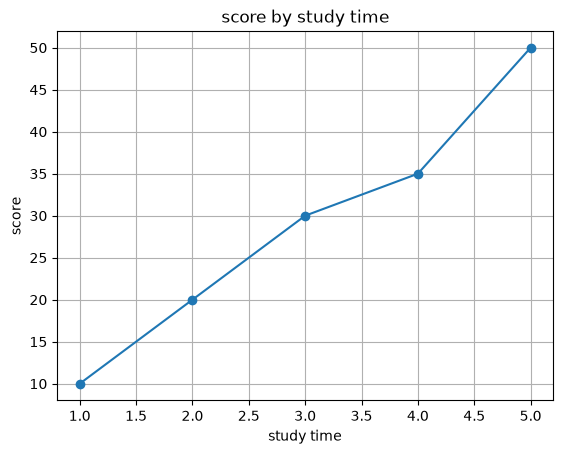

In [44]:
# 1) Line plot

x = [1, 2, 3, 4, 5]
y = [10, 20 ,30 ,35, 50]
plt.plot(x, y, marker="o")
plt.xlabel("study time")
plt.ylabel("score")
plt.title("score by study time")
plt.grid(True)
plt.show()

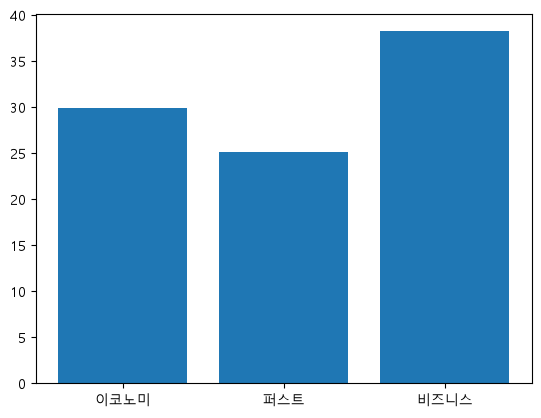

In [52]:
# 2) Bar plot
# Pclass 별 Age의 평균을 막대그래프
x = df_tt3["Pclass"].unique()
y = df_tt3.groupby("Pclass")["Age"].mean()

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


plt.bar(df_tt3["Pclass"].unique(), df_tt3.groupby("Pclass")["Age"].mean())
plt.show()

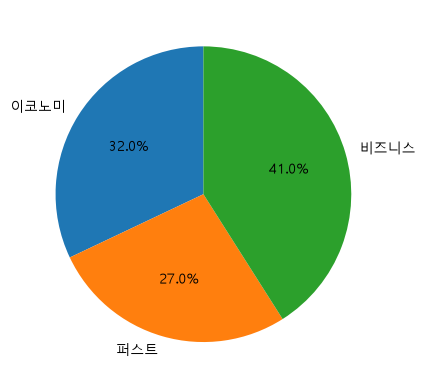

In [58]:
# 2) Bar plot
# Pclass 별 Age의 평균을 막대그래프
x = df_tt3["Pclass"].unique()
y = df_tt3.groupby("Pclass")["Age"].mean()

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


plt.pie(y, labels=x, autopct="%.1f%%", startangle=90)
plt.show()

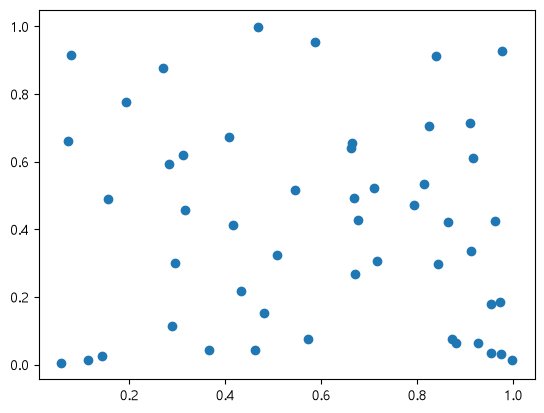

In [64]:
x_random = np.random.rand(50)
y_random = np.random.rand(50)

# 산점도
plt.scatter(x_random, y_random)
plt.show()

In [74]:
# 상관계수 분석
df_tt4 = df_titanic.iloc[:,:6].copy()
df_tt4 = df_tt4.dropna()

df_tt4["Sex"] = df_tt4["Sex"].map({"female":1, "male":0})

df_corr = df_tt4[["Survived", "Pclass", "Sex", "Age"]].copy()
df_corr.corr()
# 두 변수간의 관계를 수치로 표현
# 1에 가까울수록 양의 상관관계
# -1에 가까울수록 음의 상관관계



,Survived,Pclass,Sex,Age
Survived,1.000000,-0.359653,0.538826,-0.077221
Pclass,-0.359653,1.000000,-0.155460,-0.369226
Sex,0.538826,-0.155460,1.000000,-0.093254
Age,-0.077221,-0.369226,-0.093254,1.000000


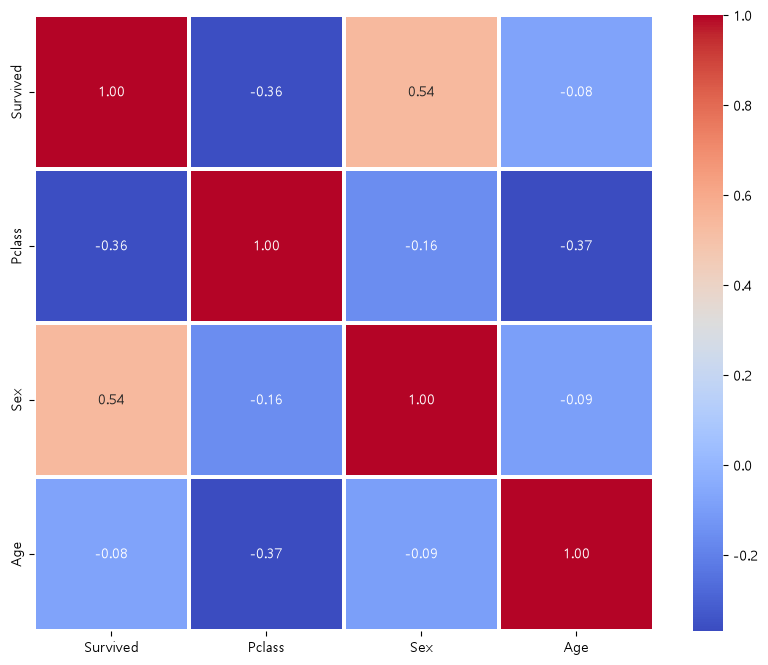

In [ ]:
plt.figure(figsize=(10, 8)) # plt 크기 조절 
sns.heatmap(df_corr.corr(), cmap="coolwarm", annot=True, linewidths=1.5, fmt=".2f")
plt.show()

In [ ]:
print(sklearn.__version__)
# 도마뱀책 1-7 p.38

iris_dataset = load_iris()  # sklearn이 제공하는 Bunch타입, 우리 Dictionary처럼 사용해보자
iris_dataset.keys()
iris_dataset["data"]        # ndarray
iris_dataset["data"].ndim   # dimension(차원)
iris_dataset["data"].shape  # 모양! (행, 열)
# 150개 row(data), 4개의 column (feature)
#print(iris_dataset.DESCR)
iris_dataset.target # Label

iris_dataset.target_names  # Label 0 -> setosa, 1 -> versicolor, 2 -> virginica
iris_dataset.feature_names # column의 의미
iris_dataset.keys()

1.9.0


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [81]:
# 백터 연산 O(n)
# 사용 이유 빠르다!! (numpy 라이브러리가 c언어 기반이기에)
arr1 = np.array([1, 2, 3, 4, 5])
arr2 = np.array([6, 7, 8, 9, 10])
print(arr1)
print(arr2)
print(arr1 + arr2)

list1 = [1, 2, 3, 4, 5]
list2 = [6, 7, 8, 9, 10]

# 시간 복잡도가 O(n) : for 문 한 바퀴 돌아야 하는구나
for num1, num2 in zip(list1, lsit2):
    print(num1 + num2, end=" ")

[1 2 3 4 5]
[ 6  7  8  9 10]
[ 7  9 11 13 15]


NameError: name 'lsit2' is not defined

In [99]:
# 현재 데이터는 (150, 4)
# 150개의 data, 4개의 feature
# 머신러닝 통해서 규칙을 찾는다 -> 모델, 알고리즘을 만든다

# 해당 모델을 만들었으면
# 새로운 상황에 대해(4개의 feature 을 가진) 어떤 class 인지(0, 1, 2) 예측

# 지나가다 붓꽃(iris)을 발견
# 꽃잎의 길이, 너비, 꽃받침의 길이, 너비 -> 총 4개의 feature를 재서
# 우리 모델에 돌리면 -> 어떤 품종인지 짜잔 나옵니다

# 모델, 알고리즘을 만드는 데 사용되는 데이터 -> 학습 데이터(train dataset)
# 실제 모델이 잘 만들어졌는지 확인용 데이터 -> 테스트 데이터(test data)

# 150개 데이터 -> train, test로 분리(split)
# 보편적으로 7:3, 8:2
# input (대문자 X)
X = iris_dataset.data  
# label (소문자 y)
y = iris_dataset.target

train_test_split(X, y)[0].shape  #(112, 4)
train_test_split(X, y)[1].shape  #(38, 4)
train_test_split(X, y)[2].shape  #(112, )
train_test_split(X, y)[3].shape  #(38, )

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=7, train_size=0.75)
print(X_test)
print(y_test)

[[5.9 3.  5.1 1.8]
 [5.4 3.  4.5 1.5]
 [5.  3.5 1.3 0.3]
 [5.6 3.  4.5 1.5]
 [4.9 2.5 4.5 1.7]
 [4.5 2.3 1.3 0.3]
 [6.9 3.1 4.9 1.5]
 [5.6 2.7 4.2 1.3]
 [4.8 3.4 1.6 0.2]
 [6.4 3.2 4.5 1.5]
 [6.7 3.  5.  1.7]
 [6.  3.4 4.5 1.6]
 [5.2 4.1 1.5 0.1]
 [7.2 3.6 6.1 2.5]
 [5.2 3.4 1.4 0.2]
 [5.9 3.2 4.8 1.8]
 [6.7 2.5 5.8 1.8]
 [6.4 3.1 5.5 1.8]
 [5.1 3.8 1.6 0.2]
 [4.9 3.6 1.4 0.1]
 [5.8 2.7 3.9 1.2]
 [6.9 3.2 5.7 2.3]
 [6.1 2.9 4.7 1.4]
 [6.  2.2 5.  1.5]
 [7.2 3.  5.8 1.6]
 [6.  3.  4.8 1.8]
 [6.2 2.9 4.3 1.3]
 [5.5 2.4 3.8 1.1]
 [5.8 2.7 5.1 1.9]
 [6.7 3.1 5.6 2.4]
 [6.2 2.8 4.8 1.8]
 [5.7 2.6 3.5 1. ]
 [4.6 3.6 1.  0.2]
 [6.9 3.1 5.4 2.1]
 [6.4 2.9 4.3 1.3]
 [4.8 3.  1.4 0.3]
 [5.5 3.5 1.3 0.2]
 [5.4 3.9 1.7 0.4]]
[2 1 0 1 2 0 1 1 0 1 1 1 0 2 0 1 2 2 0 0 1 2 1 2 2 2 1 1 2 2 2 1 0 2 1 0 0
 0]


In [100]:
# 우리의 첫 번째 머신 러닝 모델
# K-NN : 최근접 이웃(Nearest Neighbors)

# 가장 직관적인 머신 러닝 모델
# 나는 누구인가 -> 내 이웃을 보고 결정하자
# K가 중요하다 (이웃의 개수)
# K를 3으로 둘 수 있고, 5로 할 수 있고, 7로도 할 수 있고
# 이 모델의 K를 조정하는 과정 -> parameter를 튜닝한다
# 이 때 K를 Hyper Parameter

# 우리의 KNN 모델, 초기 이웃은 3으로 설정
# 모델을 학습한다 -> fit

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train) # 주의) 절대! 학습 시 test dataset을 사용하지 않는다
y_pred = knn.predict(X_test)
print(f"실제값 : {y_test}\n예측값 : {y_pred}")


# 정확도 측정( y_test 와 y_pred 가 일치하는지 여부)
# 순서가 중요하다
print(f"정확도 : {accuracy_score(y_test, y_pred):.2f}")

실제값 : [2 1 0 1 2 0 1 1 0 1 1 1 0 2 0 1 2 2 0 0 1 2 1 2 2 2 1 1 2 2 2 1 0 2 1 0 0
 0]
예측값 : [2 1 0 1 1 0 1 1 0 1 2 1 0 2 0 1 2 2 0 0 1 2 1 1 2 2 1 1 2 2 2 1 0 2 1 0 0
 0]
정확도 : 0.92


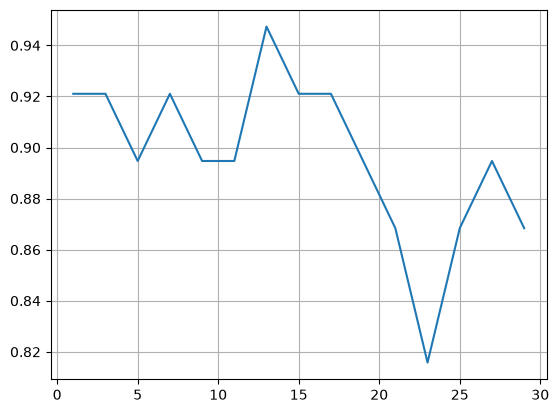

In [101]:
# 그렇다면 K값에 따라 정확도가 달라질까?
K_list = range(1, 30, 2)
acc_list = []
for K in K_list:
    knn_custom = KNeighborsClassifier(n_neighbors=K)
    knn_custom.fit(X_train, y_train)
    y_pred = knn_custom.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    acc_list.append(acc)

# 정확도를 시각화
x_knn = list(K_list)
y_knn = acc_list
plt.plot(x_knn, y_knn)
plt.grid(True)
plt.show()


In [103]:
# 모델 성능
# 과소적합(Underfitting)

# 기온 20도 아이스크림 판매량 100개
# 기온 25도 아이스크림 판매량 200개
# 기온 30도 아이스크림 판매량 300개

# 모델이 너무 단순하다
# feature가 적다. pattern을 제대로 파악하지 못함
# 개선 방법 : feature를 늘린다. = much complicated model을 사용한다


# 과대적합(overfitting)
# train통해 model 만들고 test까지 기가막히게 정확도가 높음 
# but, 실제 data를 예측 잘 못함
# 학습된 상황은 잘 맞추는데 실제 상황은 잘 못맞춘다
# 개선 방법 : 더 많은 데이터 확보, feature을 제한 = more simply

# 과소적합과 과대적합을 잘 조절해서 일반화(generalization) => Ideal goal

# 과소적합, 과대적합, 일반화
# 과소적합: 학습 성능 낮다, 테스트 성능 낮다
# 과대적합: 학습 성능 높다, 테스트 성능 낮다
# 일반화  : 학습 성능 높다, 테스트 성능 높다 


In [148]:
# 의사 결정 트리(Desicion Tree)
# feature 에 대한 질문을 토대로 분류하는 모델

wine_dataset = load_wine()
wine_dataset.data.shape # (178,13)
X_wine = wine_dataset.data
y_wine = wine_dataset.target
# from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=20)

In [152]:
d_tree = DecisionTreeClassifier(max_depth=3, random_state=20)  # 3인 이유 : 과적합 방비
d_tree.fit(X_train, y_train)
y_pred = d_tree.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"정확도 : {accuracy:.2f}")

정확도 : 0.92


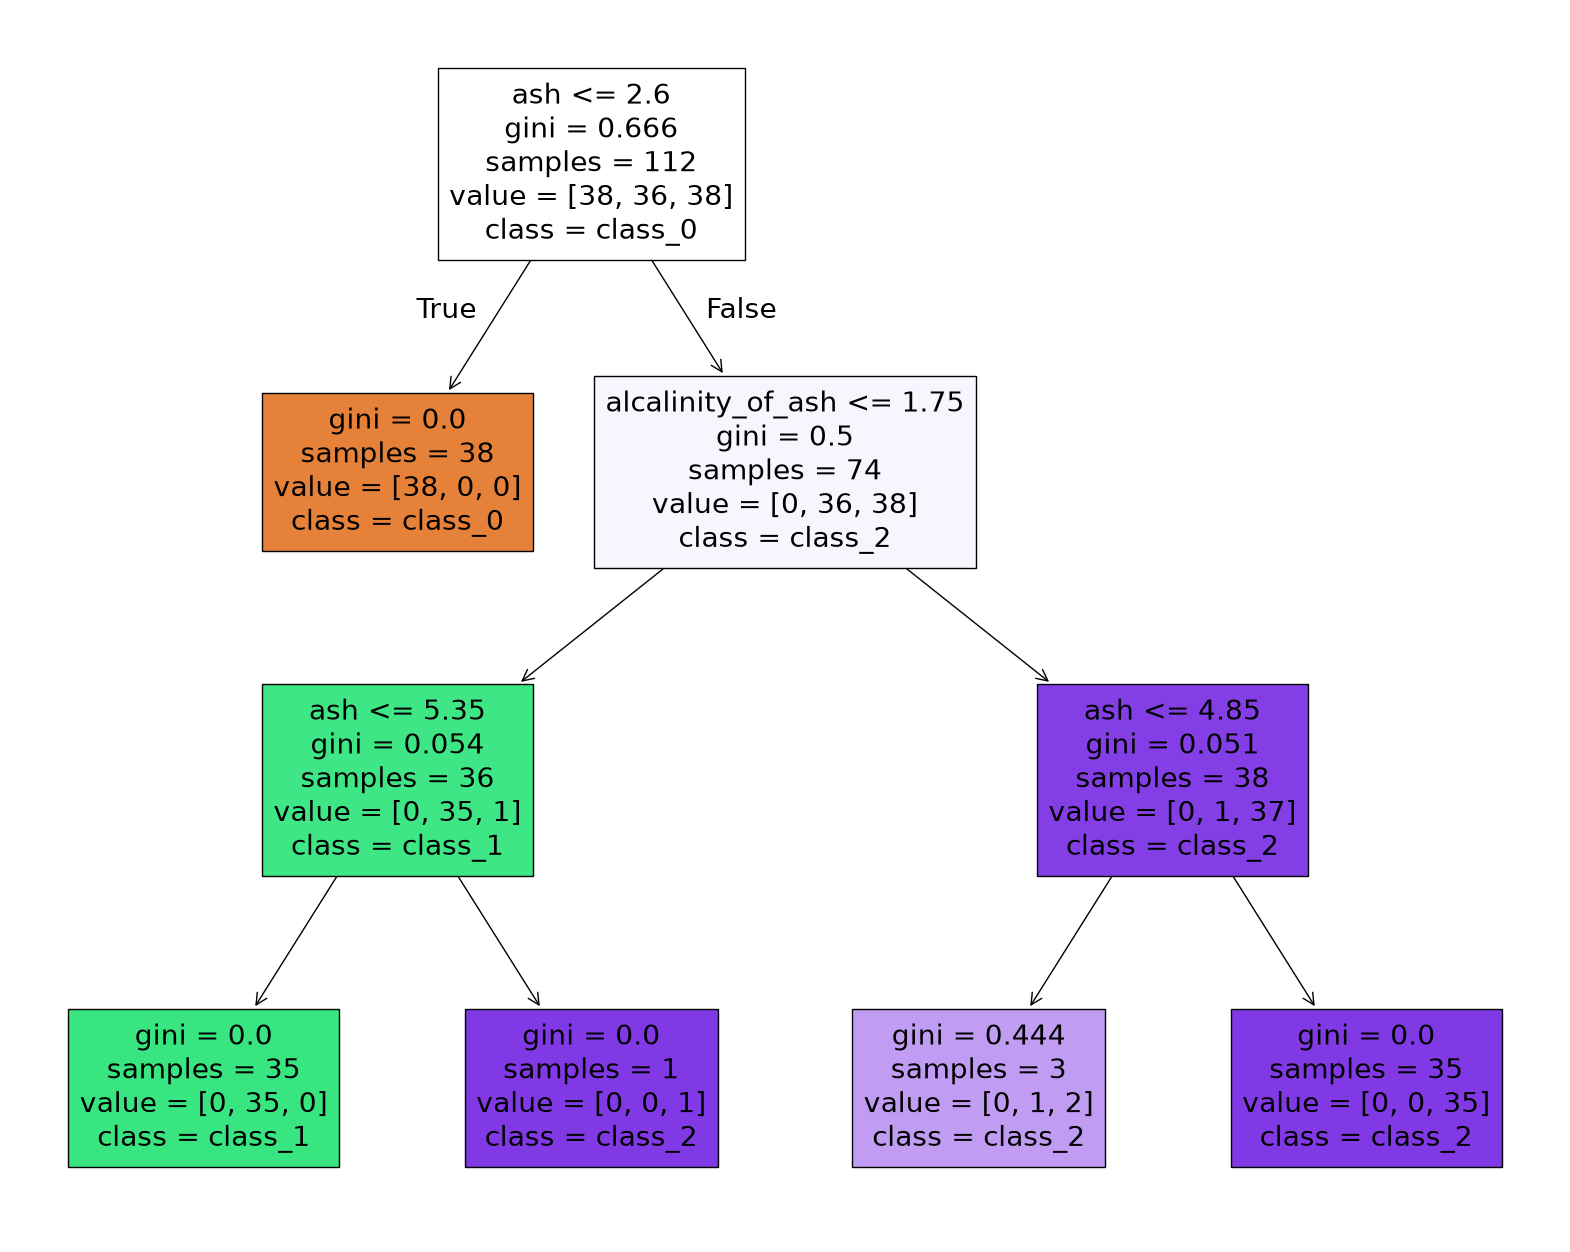

In [153]:
# 의사 결정 트리 시각화
# 불순도 : 의사결정트리에서 질문을 하고자 하는 노드에 얼마나 다양한 클래스들이 섞여있는가?
# gini impurity(지니 불순도) : 이진분류에서 순수할수록 0, 불순할수록 0.5 에 가깝다.
# 총 10개의 두 색깔의 공
# 빨간색 공, 파란색 공
# 두개를 꺼냈을 때 다른 공이 나올 확률
# 총 10개, (빨강, 파랑)
# (10, 0)  : 0
# (7, 3)   : 0.46
# (5, 5)   : 0.55
# (3, 7)   : 0.46
# (0, 10)  : 0

# 의사 결정 나무
# gini 계수가 순수하도록 (0에 가까워지도록) 질문을 정한다.

# 장점 : 어떤 규칙에 의거해서 분류되는지 명확하다 = human friendly (시각화, 전처리, 표현 쉬움)
# 단점 : overfitting(과적합) 되기 쉽다, random_state로 랜덤하게 던진 질문에 의해 모델 성능이 급격히 낮아질 수 있다.
# 해결방법 : limited max_depth, 노드에 들어가는 최소 데이터 수 제한(min_samples_leaf=num)


plt.figure(figsize=(20,16))
plot_tree(d_tree, filled=True, feature_names=wine_dataset.feature_names, class_names=wine_dataset.target_names)
plt.show()

In [158]:
# 어떤 feature가 impurity에 가장 많은 영향을 미치는가
f_i = d_tree.feature_importances_
f_n = wine_dataset.feature_names
df_wine = pd.DataFrame({"특징":f_n, "중요도":f_i})
df_wine

ValueError: All arrays must be of the same length

In [ ]:
# 마지막 교시
# 1) wine데이터를 KNN
# 2) iris데이터를 의사결정나무
# 3) 새로운 데이터(유방암) KNN
# 4) 새로운 데이터(유방암) 의사결정나무b

In [ ]:
# 1) wine데이터를 KNN
wine_dataset = load_wine()
wine_dataset.data.shape # (178,13)
wine_dataset.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [176]:
# input (대문자 X)
X_wine = wine_dataset.data  
# label (소문자 y)
y_wine = wine_dataset.target

In [177]:
X_train, X_test, y_train, y_test = train_test_split(X_wine, y_wine, random_state=20)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train) # 주의) 절대! 학습 시 test dataset을 사용하지 않는다
y_pred = knn.predict(X_test)
print(f"실제값 : {y_test}\n예측값 : {y_pred}")


# 정확도 측정( y_test 와 y_pred 가 일치하는지 여부)
# 순서가 중요하다
print(f"정확도 : {accuracy_score(y_test, y_pred):.2f}")

실제값 : [1 2 0 1 1 1 2 1 1 2 0 2 1 1 0 1 1 0 0 2 2 0 1 0 2 1 0 2 1 1 1 1 2 1 0 0 0
 1 2 1 0 0 1 1 1]
예측값 : [1 1 0 2 1 2 2 1 1 2 0 2 2 2 0 1 1 0 0 0 0 0 1 0 1 2 0 2 1 1 2 1 1 2 0 0 0
 1 2 1 0 2 1 1 2]
정확도 : 0.69


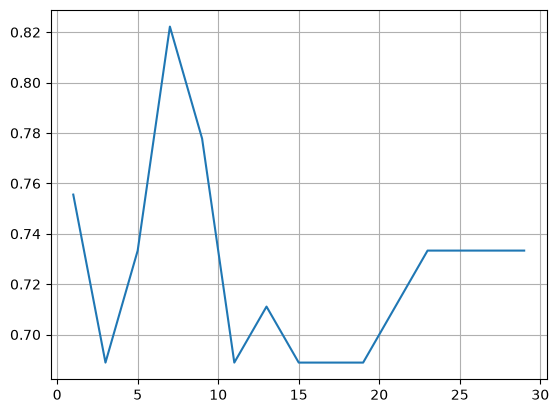

In [179]:
# 그렇다면 K값에 따라 정확도가 달라질까?
K_list = range(1, 30, 2)
acc_list = []
for K in K_list:
    knn_custom = KNeighborsClassifier(n_neighbors=K)
    knn_custom.fit(X_train, y_train)
    y_pred = knn_custom.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    acc_list.append(acc)

# 정확도를 시각화
x_knn = list(K_list)
y_knn = acc_list
plt.plot(x_knn, y_knn)
plt.grid(True)
plt.show()

In [ ]:
# 2) iris데이터를 의사결정나무
iris_dataset = load_iris()
iris_dataset.data.shape # (178,13)
iris_dataset.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [183]:
X_iris = iris_dataset.data
y_iris = iris_dataset.target
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, random_state=20)

In [184]:
d_tree = DecisionTreeClassifier(max_depth=3, random_state=20)  # 3인 이유 : 과적합 방비
d_tree.fit(X_train, y_train)
y_pred = d_tree.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"정확도 : {accuracy:.2f}")

정확도 : 0.92


In [ ]:
# 3) 새로운 데이터(유방암) KNN

breast_cancer_dataset = load_breast_cancer()
breast_cancer_dataset.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [239]:
#print(breast_cancer_dataset['data'])
#print(breast_cancer_dataset['target'])
#print(breast_cancer_dataset['DESCR'])
#print(breast_cancer_dataset.DESCR)
print(breast_cancer_dataset.data)

[[1.799e+01 1.038e+01 1.228e+02 ... 2.654e-01 4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 ... 1.860e-01 2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 ... 2.430e-01 3.613e-01 8.758e-02]
 ...
 [1.660e+01 2.808e+01 1.083e+02 ... 1.418e-01 2.218e-01 7.820e-02]
 [2.060e+01 2.933e+01 1.401e+02 ... 2.650e-01 4.087e-01 1.240e-01]
 [7.760e+00 2.454e+01 4.792e+01 ... 0.000e+00 2.871e-01 7.039e-02]]


In [189]:
X_breast_cancer_dataset = breast_cancer_dataset.data
y_breast_cancer_dataset = breast_cancer_dataset.target

In [230]:
X_train, X_test, y_train, y_test = train_test_split(X_breast_cancer_dataset, y_breast_cancer_dataset, random_state=310)

In [ ]:
knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

In [216]:
accuracy = accuracy_score(y_test, y_pred)

In [217]:
print(f"정확도 : {accuracy:.4f}")

정확도 : 0.9301


In [232]:
# 4) 새로운 데이터(유방암) 의사결정나무
d_tree = DecisionTreeClassifier(max_depth=3)
d_tree.fit(X_train, y_train)
y_pred = d_tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

In [233]:
print(f"정확도 : {accuracy:.4f}")

정확도 : 0.9231


In [ ]:
# 매번 선언해야하는지? >>> 한번만 해도 되는 듯
# knn = KNeighborsClassifier(n_neighbors=3)
# d_tree = DecisionTreeClassifier(max_depth=3)

# d_tree 에서 random_state가 달라도 되는지
# X_train, X_test, y_train, y_test = train_test_split(X_breast_cancer_dataset, y_breast_cancer_dataset, random_state=310)
# d_tree = DecisionTreeClassifier(max_depth=3, random_state=20) >>>이것의 random_state가 영향이 없어보인다.(지워도 문제가 없다.)

In [ ]:
# 내일 수업
# SVM(Support Vector Machine)
# 지도 학습 중 회귀(Regression)
# 평가 지표 중 MAE, MSE, RMSE, R^2
# 분류 모델로 AND GATE 구현

# 비지도 학습
# 군집 알고리즘(Clustering)
# - 엘보우 기법 등
# * 시간 되면 밀도 기반 군집 알고리즘 (신나는 eps 찾기)
# 차원 축소

# 전처리
# 레이블 인코딩
# 원-핫 인코딩
# * 시간 되면 연관 규칙 분석 (지지도, 신뢰도 등)
# * 결측치 처리 기법

# 타이타닉~ KNN, 의사결정나무 등

# * 시간 되면 이상 탐지

# 로지스틱 회귀(사실 분류임)
# * 앙상블
# 평가 지표
# 신나는 혼돈 행렬 (TN, FP, FN, TP)
# ROC 곡선

# 딥 러닝 기초 (퍼센트론)
# 일차 함수, 이차 함수, 미분, 편미분
# 손으로 딥 러닝 모델 만들기